# Text-to-Image GAN for MNIST Digit Generation

## Problem Statement

The goal of this notebook is to build a Text-to-Image GAN that generates handwritten digit images from simple text prompts.

Text-to-Image GANs generate images based on natural language descriptions. Large-scale systems usually require image-caption datasets and powerful models. This notebook uses a compact and reliable educational setup with MNIST.

Each MNIST digit image is paired with a text description such as:

- `digit zero`
- `digit five`
- `handwritten digit nine`

The Generator receives both random noise and a text prompt embedding. The Discriminator receives both an image and the corresponding text prompt, then predicts whether the image-text pair is real or generated.

## Objectives

By the end of this notebook, we will:

1. Load and preprocess the MNIST dataset.
2. Create text descriptions for digit classes.
3. Convert text prompts into numerical embeddings.
4. Build a text-conditioned Generator.
5. Build a text-conditioned Discriminator.
6. Train the Text-to-Image GAN using TensorFlow and Keras.
7. Generate digit images from custom text prompts.
8. Understand the basic workflow behind Text-to-Image GANs.

## Expected Outcome

After training, the Generator should produce synthetic 28x28 grayscale handwritten digit images that match simple text prompts. For example, a prompt such as `digit seven` should guide the model toward generating an image that resembles a handwritten 7.

This is a compact demonstration. It is designed to explain the text-conditioning concept clearly and run successfully in Google Colab.

## 1. Import Required Libraries

This notebook uses TensorFlow/Keras, NumPy, and Matplotlib. These libraries are available in Google Colab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

# Make the experiment reproducible as much as possible.
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Preprocess the Dataset

We use the MNIST dataset, which contains 28x28 grayscale images of handwritten digits.

The Generator uses `tanh` in the final layer, so real images are scaled to the range `[-1, 1]`.

In [2]:
# Load MNIST images and labels.
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

# Convert images to float32 for neural network training.
x_train = x_train.astype("float32")

# Scale pixel values from [0, 255] to [-1, 1].
x_train = (x_train - 127.5) / 127.5

# Flatten each 28x28 image into a vector of 784 values.
x_train = x_train.reshape(x_train.shape[0], 784)

# Labels are integer class IDs from 0 to 9.
y_train = y_train.astype("int32")

print("Training image shape:", x_train.shape)
print("Training label shape:", y_train.shape)
print("Unique labels:", np.unique(y_train))
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training image shape: (60000, 784)
Training label shape: (60000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Minimum pixel value: -1.0
Maximum pixel value: 1.0


## 3. Create Text Prompts for Each Digit

A real Text-to-Image GAN is trained with image-caption pairs. For this educational example, each digit label is converted into a short text prompt.

Multiple prompt templates are used so the model sees small language variations during training.

In [3]:
digit_words = {
    0: "zero",
    1: "one",
    2: "two",
    3: "three",
    4: "four",
    5: "five",
    6: "six",
    7: "seven",
    8: "eight",
    9: "nine",
}

prompt_templates = [
    "digit {word}",
    "handwritten digit {word}",
    "number {word}",
]


def label_to_prompt(label):
    """Converts a numeric digit label into a text prompt."""
    template_index = np.random.randint(0, len(prompt_templates))
    template = prompt_templates[template_index]
    return template.format(word=digit_words[int(label)])


# Create one text prompt for every image in the training set.
text_prompts = np.array([label_to_prompt(label) for label in y_train])

print("Example prompts:")
for prompt in text_prompts[:10]:
    print(prompt)

Example prompts:
number five
digit zero
number four
number one
digit nine
digit two
number one
handwritten digit three
number one
number four


## 4. Convert Text Prompts into Token Sequences

Neural networks need numerical inputs. The `TextVectorization` layer converts text prompts into fixed-length token sequences.

In [4]:
# Maximum number of tokens in each prompt.
MAX_TOKENS_PER_PROMPT = 4

# Vocabulary size is small because the prompt language is simple.
VOCAB_SIZE = 50

text_vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_TOKENS_PER_PROMPT,
)

# Learn the vocabulary from the training prompts.
text_vectorizer.adapt(text_prompts)

# Convert all text prompts to integer token sequences.
prompt_sequences = text_vectorizer(text_prompts).numpy().astype("int32")

print("Vocabulary:", text_vectorizer.get_vocabulary())
print("Prompt sequence shape:", prompt_sequences.shape)
print("First prompt:", text_prompts[0])
print("First token sequence:", prompt_sequences[0])

Vocabulary: ['', '[UNK]', np.str_('digit'), np.str_('handwritten'), np.str_('number'), np.str_('one'), np.str_('seven'), np.str_('three'), np.str_('two'), np.str_('nine'), np.str_('zero'), np.str_('six'), np.str_('eight'), np.str_('four'), np.str_('five')]
Prompt sequence shape: (60000, 4)
First prompt: number five
First token sequence: [ 4 14  0  0]


## 5. Define Hyperparameters

These settings control the latent noise size, text embedding size, batch size, and training duration. Increasing `EPOCHS` usually improves generated image quality.

In [5]:
# Size of random noise vector provided to the Generator.
LATENT_DIM = 100

# Size of each token embedding.
TOKEN_EMBEDDING_DIM = 32

# Size of the final prompt embedding used for conditioning.
TEXT_EMBEDDING_DIM = 64

# Number of samples processed in one training step.
BATCH_SIZE = 128

# Number of complete passes through the training dataset.
EPOCHS = 10

# Optimizer settings commonly used in GAN training.
LEARNING_RATE = 0.0002
BETA_1 = 0.5

# Number of generated images displayed during visualization.
NUM_EXAMPLES_TO_GENERATE = 10

## 6. Build a Shared Text Encoder

The text encoder converts token sequences into dense prompt embeddings. The same encoder is used by both the Generator and the Discriminator so both models learn from the same text representation.

In [6]:
def build_text_encoder(vocab_size, token_embedding_dim, text_embedding_dim):
    """Builds a small text encoder for prompt conditioning."""
    inputs = layers.Input(shape=(MAX_TOKENS_PER_PROMPT,), dtype="int32", name="prompt_tokens")

    x = layers.Embedding(vocab_size, token_embedding_dim, mask_zero=True)(inputs)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(text_embedding_dim)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    return models.Model(inputs, x, name="Text_Encoder")


actual_vocab_size = len(text_vectorizer.get_vocabulary())
text_encoder = build_text_encoder(actual_vocab_size, TOKEN_EMBEDDING_DIM, TEXT_EMBEDDING_DIM)
text_encoder.summary()

Model: "Text_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ prompt_tokens       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 32)     │        480 │ prompt_tokens[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 4)         │          0 │ prompt_tokens[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64)        │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,592 (10.12 KB)

 Trainable params: 2,592 (10.12 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Build the Text-Conditioned Generator

The Generator receives two inputs:

1. Random noise.
2. A tokenized text prompt.

The text prompt is encoded and concatenated with noise, allowing the Generator to create an image that matches the prompt.

In [7]:
def build_generator(latent_dim):
    """Builds a text-conditioned Generator."""
    noise_input = layers.Input(shape=(latent_dim,), name="noise_input")
    prompt_input = layers.Input(shape=(MAX_TOKENS_PER_PROMPT,), dtype="int32", name="prompt_input")

    text_embedding = text_encoder(prompt_input)

    # Combine visual randomness with text condition.
    x = layers.Concatenate()([noise_input, text_embedding])

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)

    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)

    # The output is a flattened 28x28 grayscale image with values in [-1, 1].
    image_output = layers.Dense(784, activation="tanh", name="generated_image")(x)

    return models.Model([noise_input, prompt_input], image_output, name="Text_to_Image_Generator")


generator = build_generator(LATENT_DIM)
generator.summary()

Model: "Text_to_Image_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ prompt_input        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Text_Encoder        │ (None, 64)        │      2,592 │ prompt_input[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 164)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ Text_Encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     42,240 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 256)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ leaky_re_lu_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 512)       │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ leaky_re_lu_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024)      │    525,312 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 1024)      │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ leaky_re_lu_3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generated_image     │ (None, 784)       │    803,600 │ batch_normalizat… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,512,496 (5.77 MB)

 Trainable params: 1,508,912 (5.76 MB)

 Non-trainable params: 3,584 (14.00 KB)

## 8. Build the Text-Conditioned Discriminator

The Discriminator receives two inputs:

1. An image.
2. The text prompt associated with that image.

It predicts whether the image-text pair is real or generated.

In [8]:
def build_discriminator():
    """Builds a text-conditioned Discriminator."""
    image_input = layers.Input(shape=(784,), name="image_input")
    prompt_input = layers.Input(shape=(MAX_TOKENS_PER_PROMPT,), dtype="int32", name="prompt_input")

    text_embedding = text_encoder(prompt_input)

    # Combine image features with prompt features.
    x = layers.Concatenate()([image_input, text_embedding])

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)

    validity_output = layers.Dense(1, activation="sigmoid", name="validity")(x)

    return models.Model([image_input, prompt_input], validity_output, name="Text_to_Image_Discriminator")


discriminator = build_discriminator()
discriminator.summary()

Model: "Text_to_Image_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ prompt_input        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Text_Encoder        │ (None, 64)        │      2,592 │ prompt_input[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 848)       │          0 │ image_input[0][0… │
│ (Concatenate)       │                   │            │ Text_Encoder[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    434,688 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 512)       │          0 │ dense_4[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 256)       │          0 │ dense_5[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validity (Dense)    │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 568,865 (2.17 MB)

 Trainable params: 568,865 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Configure Loss Functions and Optimizers

The Discriminator learns to classify real image-text pairs as real and generated image-text pairs as fake.

The Generator learns to create images that look real and match the text prompt.

In [9]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)


def discriminator_loss(real_output, fake_output):
    """Calculates Discriminator loss for real and generated image-text pairs."""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss


def generator_loss(fake_output):
    """Calculates Generator loss based on fooling the Discriminator."""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

## 10. Prepare the Training Dataset

The dataset returns image-prompt pairs. Text prompts are represented by token sequences.

In [10]:
train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, prompt_sequences))
    .shuffle(buffer_size=x_train.shape[0])
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Number of batches per epoch:", tf.data.experimental.cardinality(train_dataset).numpy())

Number of batches per epoch: 468


## 11. Define the Training Step

Each training step updates both models:

1. The Generator creates images from random noise and text prompts.
2. The Discriminator evaluates real image-text pairs and generated image-text pairs.
3. The Discriminator is updated to improve classification.
4. The Generator is updated to produce better prompt-matched images.

In [11]:
@tf.function
def train_step(real_images, real_prompts):
    """Runs one Text-to-Image GAN training step."""
    batch_size = tf.shape(real_images)[0]

    # Random noise provides variation in generated images.
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, real_prompts], training=True)

        real_output = discriminator([real_images, real_prompts], training=True)
        fake_output = discriminator([generated_images, real_prompts], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

## 12. Helper Functions for Text-to-Image Generation

These functions convert custom text prompts into token sequences and display generated images.

In [16]:
seed_prompts = np.array([
    "digit zero",
    "digit one",
    "digit two",
    "digit three",
    "digit four",
    "digit five",
    "digit six",
    "digit seven",
    "digit eight",
    "digit nine",
])

seed_prompt_sequences = text_vectorizer(seed_prompts).numpy().astype("int32")
seed_noise = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])


def prompts_to_sequences(prompts):
    """Converts text prompts into integer token sequences."""
    prompts = np.array(prompts)
    return text_vectorizer(prompts).numpy().astype("int32")


def display_generated_images(model, epoch, noise, prompt_sequences_for_display, prompt_texts):
    """Displays generated images with their text prompts."""
    # Ensure prompt_sequences_for_display is a tf.Tensor
    predictions = model([noise, tf.convert_to_tensor(prompt_sequences_for_display)], training=False)

    # Convert generated images from [-1, 1] back to [0, 1] for plotting.
    predictions = (predictions + 1.0) / 2.0
    predictions = tf.reshape(predictions, [-1, 28, 28])

    plt.figure(figsize=(10, 2))

    for i in range(predictions.shape[0]):
        plt.subplot(1, predictions.shape[0], i + 1)
        plt.imshow(predictions[i], cmap="gray")
        plt.title(prompt_texts[i].replace("digit ", ""), fontsize=8)
        plt.axis("off")

    plt.suptitle(f"Generated Images from Text Prompts After Epoch {epoch}")
    plt.tight_layout()
    plt.show()

## 13. Train the Text-to-Image GAN

GAN losses may fluctuate because the Generator and Discriminator are trained against each other. Generated image quality should be reviewed visually during training.

Epoch 01/10 | Generator Loss: 0.8975 | Discriminator Loss: 1.1466


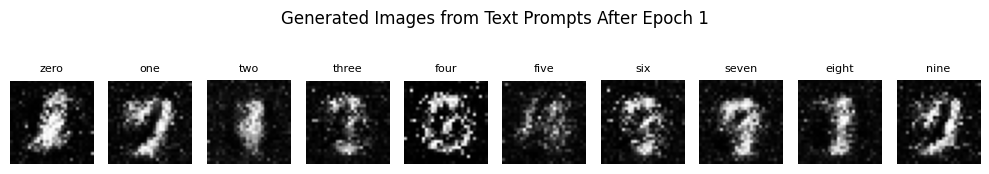

Epoch 02/10 | Generator Loss: 0.9873 | Discriminator Loss: 1.1071
Epoch 03/10 | Generator Loss: 0.9697 | Discriminator Loss: 1.1431
Epoch 04/10 | Generator Loss: 0.9394 | Discriminator Loss: 1.1846
Epoch 05/10 | Generator Loss: 0.9090 | Discriminator Loss: 1.2113


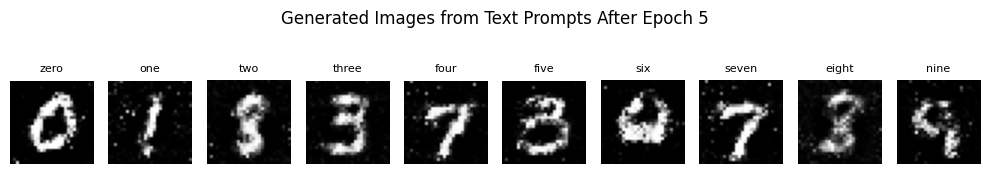

Epoch 06/10 | Generator Loss: 0.8902 | Discriminator Loss: 1.2344
Epoch 07/10 | Generator Loss: 0.8615 | Discriminator Loss: 1.2591
Epoch 08/10 | Generator Loss: 0.8621 | Discriminator Loss: 1.2614
Epoch 09/10 | Generator Loss: 0.8532 | Discriminator Loss: 1.2689
Epoch 10/10 | Generator Loss: 0.8403 | Discriminator Loss: 1.2851


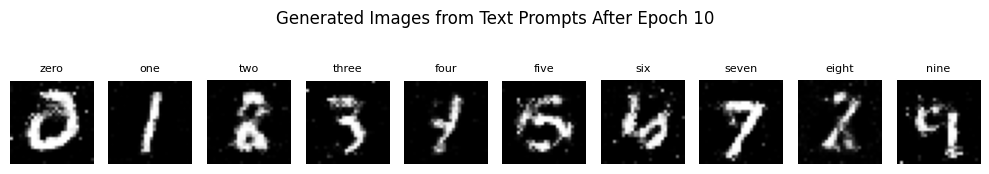

In [17]:
def train(dataset, epochs):
    """Trains the Text-to-Image GAN and displays generated samples."""
    generator_losses = []
    discriminator_losses = []

    for epoch in range(1, epochs + 1):
        epoch_gen_losses = []
        epoch_disc_losses = []

        for image_batch, prompt_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch, prompt_batch)
            epoch_gen_losses.append(gen_loss.numpy())
            epoch_disc_losses.append(disc_loss.numpy())

        avg_gen_loss = float(np.mean(epoch_gen_losses))
        avg_disc_loss = float(np.mean(epoch_disc_losses))
        generator_losses.append(avg_gen_loss)
        discriminator_losses.append(avg_disc_loss)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Generator Loss: {avg_gen_loss:.4f} | "
            f"Discriminator Loss: {avg_disc_loss:.4f}"
        )

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            display_generated_images(generator, epoch, seed_noise, seed_prompt_sequences, seed_prompts)

    return generator_losses, discriminator_losses


generator_losses, discriminator_losses = train(train_dataset, EPOCHS)

## 14. Plot Training Losses

The loss curves help monitor training behavior. In GANs, visual sample quality is usually more important than expecting perfectly smooth loss curves.

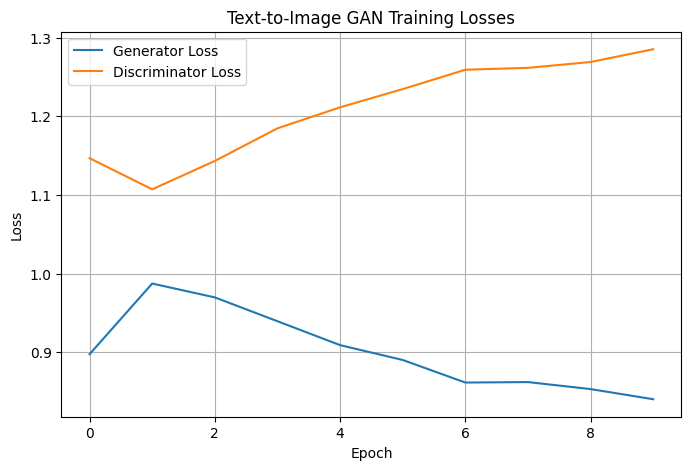

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Text-to-Image GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

## 15. Generate Images from Custom Text Prompts

The trained Generator can now create images from text prompts. The prompt vocabulary is intentionally simple, so prompts should use the digit words seen during training.

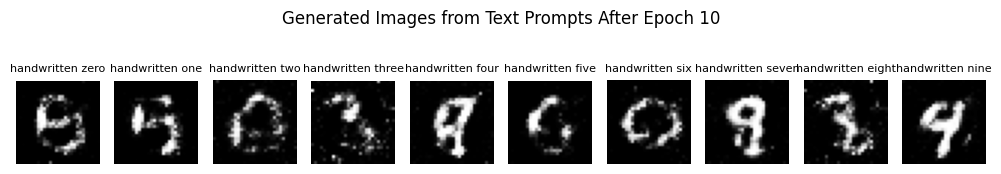

In [19]:
custom_prompts = np.array([
    "handwritten digit zero",
    "handwritten digit one",
    "handwritten digit two",
    "handwritten digit three",
    "handwritten digit four",
    "handwritten digit five",
    "handwritten digit six",
    "handwritten digit seven",
    "handwritten digit eight",
    "handwritten digit nine",
])

custom_prompt_sequences = prompts_to_sequences(custom_prompts)
custom_noise = tf.random.normal([len(custom_prompts), LATENT_DIM])

display_generated_images(generator, EPOCHS, custom_noise, custom_prompt_sequences, custom_prompts)

## Conclusion

This notebook implemented a compact Text-to-Image GAN for generating MNIST digit images from simple text prompts.

The model paired each handwritten digit image with a short text description, converted prompts into token sequences, encoded the text with a small neural network, and used the resulting text embeddings to condition both the Generator and the Discriminator.

This demonstrates the core idea of Text-to-Image GANs: generated images are not created from random noise alone, but from random noise guided by a text condition.

Full-scale Text-to-Image GANs use richer caption datasets, stronger text encoders, deeper image generators, attention mechanisms, and higher-resolution image synthesis. This notebook provides a lightweight foundation for understanding the concept before moving to advanced models such as StackGAN, AttnGAN, or modern diffusion-based text-to-image systems.